# F1 — Prédiction de Pit Stop

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='darkgrid')

---
## 1. Chargement & Préparation

### Qu'est-ce qu'une feature et une cible ?

En machine learning, on distingue deux types de colonnes :

- **Features (X)** — les informations connues au moment de la prédiction.  
  *Ex : l'usure du pneu, la position en course, la progression de la course...*

- **Cible (y)** — ce qu'on cherche à prédire.  
  *Ex : `PitNextLap` → le pilote va-t-il s'arrêter au prochain tour ? (0 = non, 1 = oui)*

Le modèle va **apprendre** la relation entre X et y sur un jeu d'entraînement, puis **prédire** y à partir de nouveaux X.

### Pourquoi encoder le composé ?

Les algorithmes ML ne comprennent que des **nombres**. La colonne `Compound` contient des textes (`SOFT`, `MEDIUM`, `HARD`...).  
On utilise un `LabelEncoder` pour convertir chaque valeur texte en entier : `HARD→0`, `INTERMEDIATE→1`, `MEDIUM→2`, etc.

### Qu'est-ce que le split train / test ?

On divise le dataset en deux parties :

| Partie | Taille | Rôle |
|---|---|---|
| **Train** | 80% | Le modèle apprend dessus |
| **Test** | 20% | On évalue le modèle sur des données qu'il n'a **jamais vues** |

Sans cette séparation, on ne saurait pas si le modèle a vraiment appris ou s'il a juste mémorisé les données (**overfitting**).

Le paramètre `stratify=y` garantit que la proportion de pit stops (≈25%) est identique dans train et test.

In [2]:
df = pd.read_csv('f1_strategy_dataset_v4.csv').dropna(subset=['Compound'])

le = LabelEncoder()
df['Compound_enc'] = le.fit_transform(df['Compound'])
print('Mapping composés :', dict(zip(le.classes_, le.transform(le.classes_))))

FEATURES = [
    'TyreLife',
    'Compound_enc',
    'Cumulative_Degradation',
    'LapTime_Delta',
    'Position',
    'RaceProgress',
    'Normalized_TyreLife',
    'Stint',
]
TARGET = 'PitNextLap'

X = df[FEATURES]
y = df[TARGET]

print(f'X : {X.shape} | y : {y.shape}')
print(f'Ratio pit stops : {y.mean():.2%}')

Mapping composés : {'HARD': np.int64(0), 'INTERMEDIATE': np.int64(1), 'MEDIUM': np.int64(2), 'SOFT': np.int64(3), 'WET': np.int64(4)}
X : (101305, 8) | y : (101305,)
Ratio pit stops : 25.46%


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')

Train : 81,044 | Test : 20,261


---
## 2. Modèle 1 — Régression Logistique

### Principe

Malgré son nom, la régression logistique est un **algorithme de classification**, pas de régression.

**Idée** : calculer une combinaison linéaire des features, puis la passer dans une fonction **sigmoïde** pour obtenir une probabilité entre 0 et 1.

```
P(pit) = sigmoid( w1×TyreLife + w2×Compound + w3×Dégradation + ... + b )
```

La fonction sigmoïde : `sigmoid(x) = 1 / (1 + e^(-x))`
- Si le résultat > 0.5 → on prédit `1` (pit stop)
- Si le résultat ≤ 0.5 → on prédit `0` (pas de pit)

Pendant l'entraînement, le modèle ajuste les **poids (w)** pour minimiser les erreurs.

### Avantages et limites

| ✅ Avantages | ❌ Limites |
|---|---|
| Simple, rapide, interprétable | Suppose une relation **linéaire** entre features et cible |
| Bonne baseline de référence | Peu performant si les relations sont complexes |
| Donne des probabilités | Sensible aux features non normalisées |

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Régression Logistique ===')
print(classification_report(y_test, y_pred_lr, target_names=['Pas de pit', 'Pit']))

=== Régression Logistique ===
              precision    recall  f1-score   support

  Pas de pit       0.78      0.95      0.86     15103
         Pit       0.59      0.21      0.31      5158

    accuracy                           0.76     20261
   macro avg       0.69      0.58      0.58     20261
weighted avg       0.73      0.76      0.72     20261



---
## 3. Modèle 2 — Random Forest

### Principe

Un Random Forest est un **ensemble d'arbres de décision** entraînés en parallèle sur des sous-échantillons aléatoires des données.

**Un arbre de décision** ressemble à un organigramme :
```
TyreLife > 20 ?
├── Oui → Dégradation > 5s ?
│         ├── Oui → PIT (1)
│         └── Non → PAS DE PIT (0)
└── Non → PAS DE PIT (0)
```

**Random Forest** construit 100 arbres différents (ici `n_estimators=100`), chacun entraîné sur :
- Un sous-ensemble **aléatoire** de lignes
- Un sous-ensemble **aléatoire** de features à chaque nœud

La prédiction finale est un **vote majoritaire** de tous les arbres.

### Pourquoi c'est plus puissant ?

Un seul arbre overfit facilement (il mémorise trop). La diversité des arbres + le vote annule les erreurs individuelles → c'est le principe du **bagging**.

| ✅ Avantages | ❌ Limites |
|---|---|
| Capture des relations **non-linéaires** | Plus lent à entraîner |
| Robuste au bruit et aux outliers | Moins interprétable qu'un seul arbre |
| Fournit une feature importance | Modèle plus lourd en mémoire |

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Pas de pit', 'Pit']))

=== Random Forest ===
              precision    recall  f1-score   support

  Pas de pit       0.93      0.97      0.95     15103
         Pit       0.88      0.78      0.83      5158

    accuracy                           0.92     20261
   macro avg       0.91      0.87      0.89     20261
weighted avg       0.92      0.92      0.92     20261



---
## 4. Évaluation

### Comment lire le classification report ?

| Métrique | Définition | Question à laquelle elle répond |
|---|---|---|
| **Precision** | Parmi les pit stops prédits, combien étaient vrais ? | Est-ce que le modèle fait beaucoup de fausses alertes ? |
| **Recall** | Parmi les vrais pit stops, combien a-t-on détecté ? | Est-ce que le modèle en rate beaucoup ? |
| **F1-score** | Moyenne harmonique precision/recall | Score global équilibré |
| **Support** | Nombre de cas réels dans le test | — |

### La matrice de confusion

Elle montre les 4 types de prédictions :

```
                    Prédit : 0       Prédit : 1
Réel : 0   │  Vrai Négatif (TN)  │  Faux Positif (FP)  │
Réel : 1   │  Faux Négatif (FN)  │  Vrai Positif (TP)  │
```

- **TN** : on prédit "pas de pit" et c'est correct
- **TP** : on prédit "pit" et c'est correct
- **FP** : on prédit "pit" à tort (fausse alarme)
- **FN** : on prédit "pas de pit" mais le pilote rentre quand même (le pire cas ici)

### La courbe ROC et l'AUC

La courbe ROC trace le **taux de vrais positifs** vs le **taux de faux positifs** pour tous les seuils de décision possibles.  
L'**AUC** (Area Under the Curve) résume la courbe en un seul nombre :
- AUC = 0.5 → modèle aléatoire (inutile)
- AUC = 1.0 → modèle parfait
- AUC > 0.85 → bon modèle en pratique

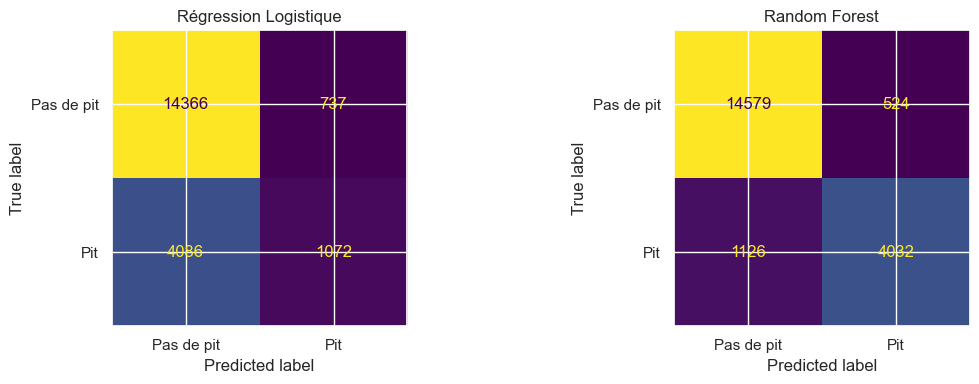

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_rf], ['Régression Logistique', 'Random Forest']):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Pas de pit', 'Pit']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

C:\Users\steve\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\steve\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


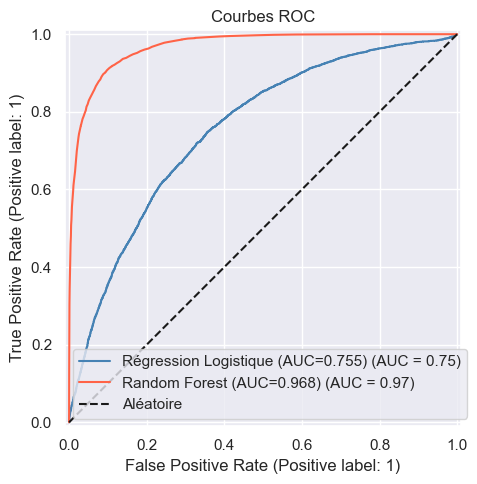

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for model, name, color in zip([lr, rf], ['Régression Logistique', 'Random Forest'], ['steelblue', 'tomato']):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    RocCurveDisplay.from_predictions(y_test, y_proba, name=f'{name} (AUC={auc:.3f})', ax=ax, color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax.set_title('Courbes ROC')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Feature Importance

### Principe

Le Random Forest peut mesurer l'**importance de chaque feature** : à quel point une variable a-t-elle contribué aux décisions de tous les arbres ?

Techniquement, c'est calculé via la **réduction d'impureté de Gini** : chaque fois qu'un nœud utilise une feature pour séparer les données, on mesure de combien l'impureté (le désordre dans les classes) a diminué. On somme ces valeurs sur tous les arbres.

**Ce que ça nous dit ici :** quelles informations sur l'état de la course sont les plus décisives pour prédire si un pilote va rentrer aux stands ?

> Une feature avec une importance élevée = le modèle s'en sert souvent pour trancher.  
> Une feature proche de 0 = elle n'apporte quasiment rien au modèle.

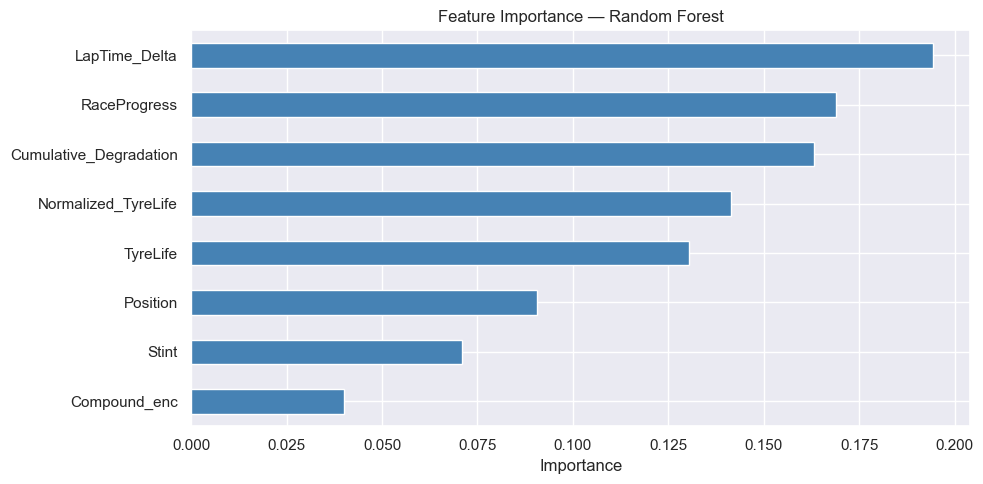

In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()